In [6]:
import csv
import shutil
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from pathlib import Path

In [7]:
ROOT = "/kaggle/input/smoke-fire-detection-yolo/data"
BAD_IMAGES_DIR = "/kaggle/working/bad_images"
BAD_LABELS_DIR = "/kaggle/working/bad_labels"
CLEAN_ROOT = "/kaggle/working/clean_data"
REPORT_CSV = "/kaggle/working/data_clean_report.csv"

In [8]:
bad_list = [
    "/kaggle/input/smoke-fire-detection-yolo/data/train/images/PublicDataset01005.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/train/images/PublicDataset00864.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/train/images/WEB04185.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/train/images/WEB02767.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/train/images/PublicDataset01036.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/train/images/PublicDataset00934.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/train/images/WEB06024.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/train/images/WEB02729.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/train/images/WEB06022.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/train/images/WEB06334.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/train/images/WEB04554.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/train/images/WEB06336.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/train/images/WEB03587.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/train/images/WEB06082.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/train/images/PublicDataset00900.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/val/images/WEB02650.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/val/images/WEB02614.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/val/images/PublicDataset01007.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/test/images/WEB10194.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/test/images/WEB10116.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/test/images/WEB10972.jpg",
    "/kaggle/input/smoke-fire-detection-yolo/data/test/images/WEB10874.jpg",
]

In [9]:
os.makedirs(BAD_IMAGES_DIR, exist_ok=True)
os.makedirs(BAD_LABELS_DIR, exist_ok=True)

for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(CLEAN_ROOT, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(CLEAN_ROOT, split, "labels"), exist_ok=True)

report_rows = []

for split in ["train", "val", "test"]:
    src_img_dir = os.path.join(ROOT, split, "images")
    src_lbl_dir = os.path.join(ROOT, split, "labels")
    dst_img_dir = os.path.join(CLEAN_ROOT, split, "images")
    dst_lbl_dir = os.path.join(CLEAN_ROOT, split, "labels")

    if not os.path.isdir(src_img_dir):
        print("Missing dir:", src_img_dir)
        continue

    for fname in sorted(os.listdir(src_img_dir)):
        src_img = os.path.join(src_img_dir, fname)

        if not os.path.isfile(src_img):
            continue

        name, _ = os.path.splitext(fname)
        src_label = os.path.join(src_lbl_dir, name + ".txt")

        if src_img in bad_list:
            shutil.copy2(src_img, BAD_IMAGES_DIR)

            if os.path.exists(src_label):
                shutil.copy2(src_label, BAD_LABELS_DIR)
                report_rows.append([split, fname, "bad_image_and_label_copied"])
            else:
                report_rows.append([split, fname, "bad_image_copied_label_missing"])
            continue

        img = cv2.imread(src_img)

        if img is None or img.size == 0:
            print(f"Invalid image: {src_img}")
            shutil.copy2(src_img, BAD_IMAGES_DIR)

            if os.path.exists(src_label):
                shutil.copy2(src_label, BAD_LABELS_DIR)
                report_rows.append([split, fname, "corrupted_image_and_label_copied"])
            else:
                report_rows.append([split, fname, "corrupted_image_copied_label_missing"])
            continue

        shutil.copy2(src_img, dst_img_dir)

        if os.path.exists(src_label):
            shutil.copy2(src_label, dst_lbl_dir)
            report_rows.append([split, fname, "copied_with_label"])
        else:
            report_rows.append([split, fname, "copied_label_missing"])

print("=" * 50)

for split in ["train", "val", "test"]:
    clean_dir = os.path.join(CLEAN_ROOT, split, "images")
    if os.path.exists(clean_dir):
        print(f"{split}: {len(os.listdir(clean_dir))} Valid Images")

train: 14107 Valid Images
val: 3096 Valid Images
test: 4302 Valid Images


In [10]:
print("=" * 50)
print(f"   Invlaid Images Save Her {BAD_IMAGES_DIR}")
print(f" Invlaid Labels Save Her: {BAD_LABELS_DIR}")

with open(REPORT_CSV, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["split", "filename", "action"])
    w.writerows(report_rows)

   Invlaid Images Save Her /kaggle/working/bad_images
 Invlaid Labels Save Her: /kaggle/working/bad_labels


In [11]:
yaml_text = f"""train: {CLEAN_ROOT}/train/images
val: {CLEAN_ROOT}/val/images
test: {CLEAN_ROOT}/test/images

nc: 2
names: ['smoke','fire']
"""
with open("/kaggle/working/data.yaml", "w", encoding="utf-8") as yf:
    yf.write(yaml_text)

print("dat.yaml is Done Created")

dat.yaml is Done Created


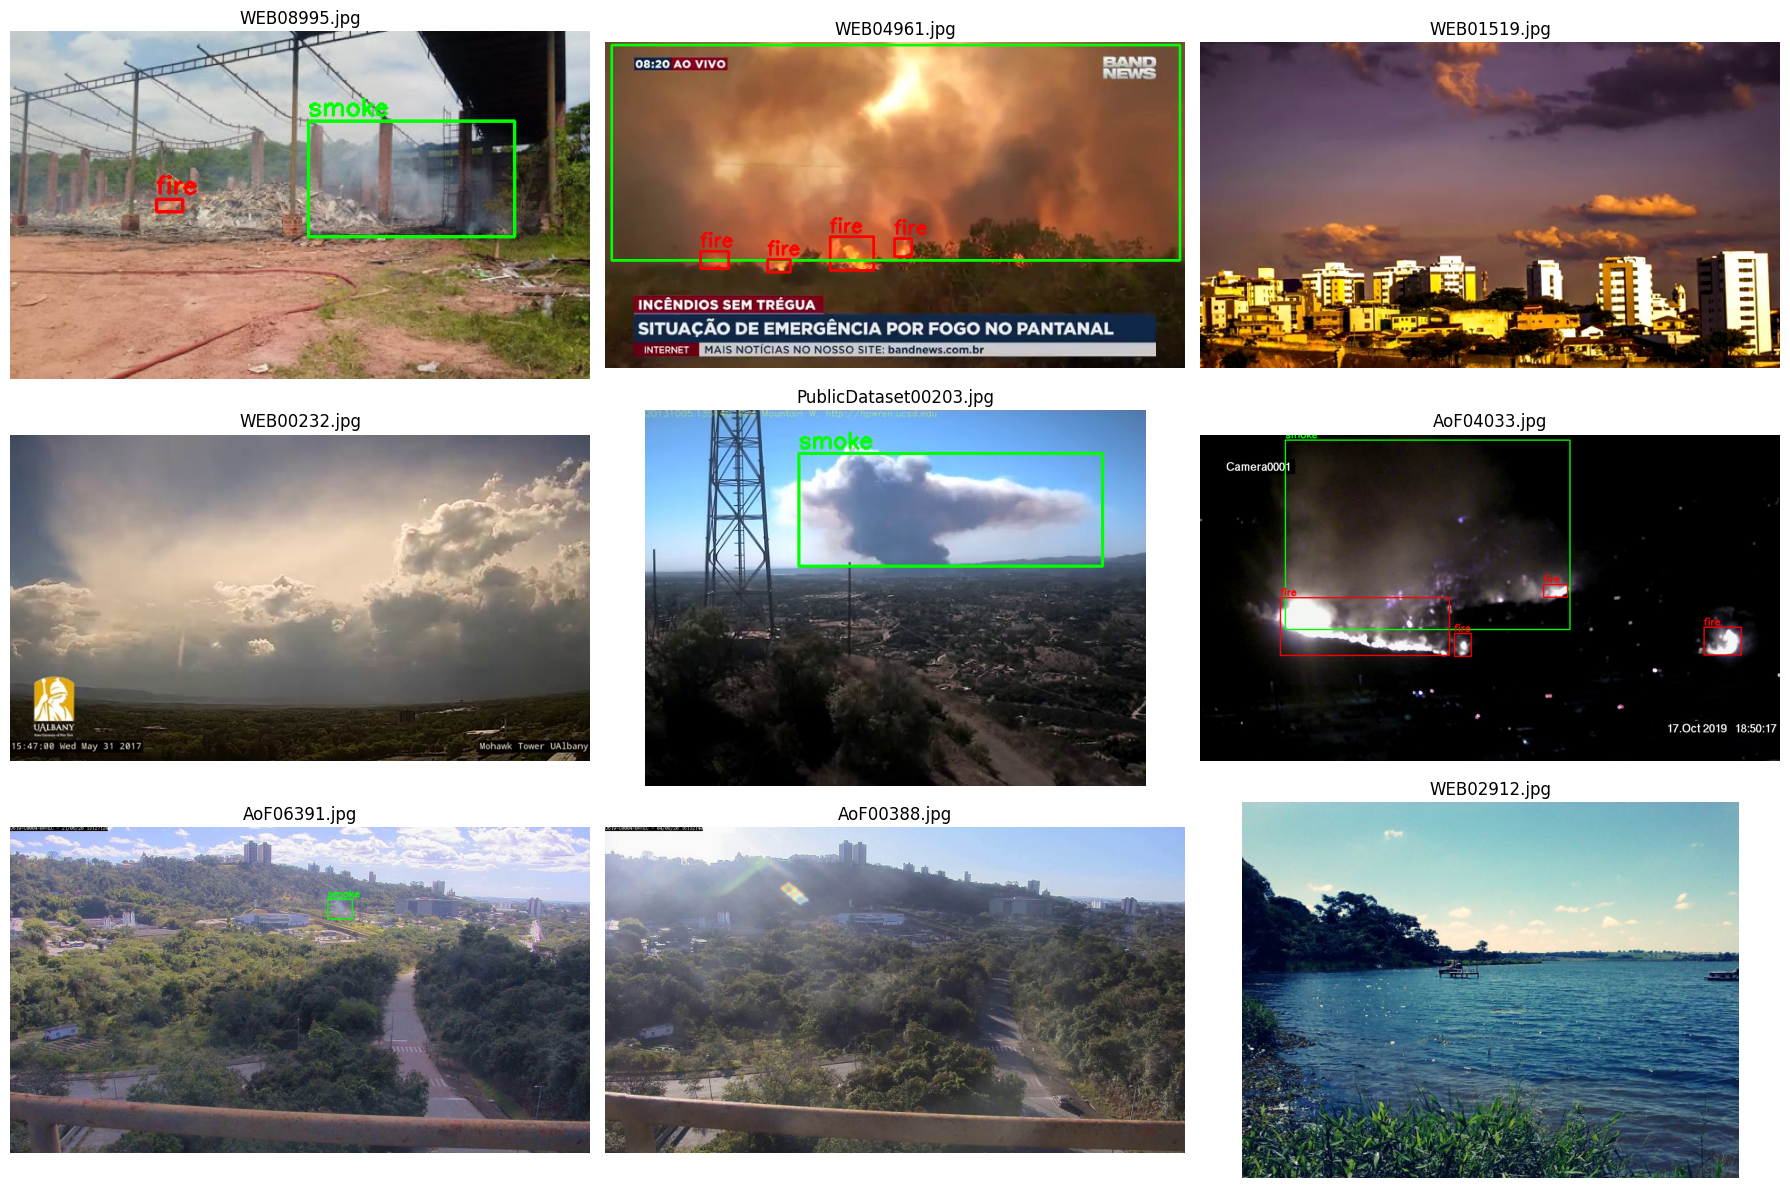

In [12]:


train_img_path = "/kaggle/input/smoke-fire-detection-yolo/data/train/images"
train_label_path = "/kaggle/input/smoke-fire-detection-yolo/data/train/labels"

sample_imgs = random.sample(os.listdir(train_img_path), 9)

def plot_image_with_boxes(img_path, label_path):
    img = cv2.imread(img_path)
    h, w, _ = img.shape
    label_file = label_path.replace('.jpg', '.txt').replace('.png', '.txt')
    if os.path.exists(label_file):
        with open(label_file, "r") as f:
            for line in f.readlines():
                cls, x_center, y_center, bw, bh = map(float, line.strip().split())
                x1 = int((x_center - bw/2) * w)
                y1 = int((y_center - bh/2) * h)
                x2 = int((x_center + bw/2) * w)
                y2 = int((y_center + bh/2) * h)
                color = (0, 255, 0) if cls == 0 else (0, 0, 255)
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                cls_name = "smoke" if cls == 0 else "fire"
                cv2.putText(img, cls_name, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

plt.figure(figsize=(18, 12))
for i, img_name in enumerate(sample_imgs):
    img_path = os.path.join(train_img_path, img_name)
    label_path = os.path.join(train_label_path, img_name)
    plt.subplot(3, 3, i+1)
    plt.imshow(plot_image_with_boxes(img_path, label_path))
    plt.axis('off')
    plt.title(img_name)
plt.tight_layout()
plt.show()

In [13]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.9 MB/s eta 0:00:00


In [14]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [15]:
model = YOLO("yolo12n.pt")

In [ ]:
results = model.train(data="/kaggle/working/data.yaml",epochs=60,imgsz=640,verbose=True)

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

In [ ]:
model.val()

In [ ]:
import shutil, glob, os

# Save immediately after training — don't wait
os.makedirs("/kaggle/working/final_model", exist_ok=True)

matches = glob.glob("/kaggle/working/runs/detect/**/weights/best.pt", recursive=True)
if matches:
    shutil.copy2(matches[-1], "/kaggle/working/final_model/fire_smoke_best.pt")
    print(f"✅ Model backed up from: {matches[-1]}")
else:
    print("❌ No best.pt found yet")